In [37]:
%pip install numpy pandas matplotlib scikit-learn

You should consider upgrading via the '/Users/aniketwagh/Code/Machine learning/01-pass-fail/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import pandas as pd

In [23]:
df = pd.read_csv("placement.csv")
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


# Data pre processing

In [ ]:
# remove unnecessary first column which is just an index
df = df.iloc[:,1:]

In [25]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


# EDA

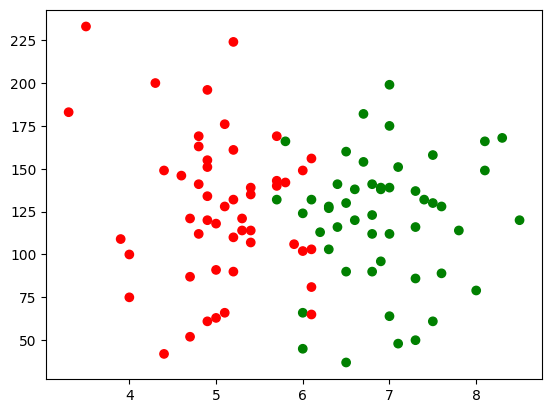

In [29]:
from matplotlib import pyplot as plt

plt.scatter(df['cgpa'], df['iq'], color = df['placement'].map({0:'red', 1:'green'}))

## Extract input output calls

In [35]:
X = df.iloc[:, :2]
Y = df.iloc[:, -1]

X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


## Train test Split

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

## Scaling

In [59]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_test

array([[-0.18613896,  1.11570604],
       [ 0.00477279, -0.39871997],
       [-1.04524188,  0.85541407],
       [-1.23615364,  0.05087525],
       [ 1.43661098, -1.36889914],
       [ 0.19568455, -0.138428  ],
       [-0.75887424,  0.31116722],
       [-0.85433012, -1.25058461],
       [ 1.91389038, -0.94296682],
       [ 1.72297862, -0.1147651 ],
       [ 0.95933159,  1.3286722 ],
       [-1.04524188, -1.36889914],
       [ 0.57750807,  0.45314466],
       [ 0.95933159, -0.16209091],
       [-0.56796248, -0.28040544],
       [-1.14069776,  1.18669476],
       [-1.04524188,  0.02721234],
       [ 0.00477279, -1.25058461],
       [ 0.86387571, -0.54069741],
       [-0.75887424,  2.48815462]])

## Train model

In [66]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

clf.fit(X_train, Y_train)

LogisticRegression()

## Model Evaluation

In [67]:
y_pred = clf.predict(X_test)

In [69]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test, y_pred)

0.95

## Store Model

In [70]:
import pickle

pickle.dump(clf, open('model.pkl', 'wb'))